**الخطوة 1: تثبيت المكتبات المطلوبة**


*   أولاً، نقوم بتثبيت المكتبات الضرورية لاستخراج وتحليل البيانات من ملف PDF.


In [ ]:
!pip uninstall pymupdf -y
!pip install pymupdf
!pip install pytesseract pdf2image pillow pandas fitz openpyxl python-bidi arabic-reshaper

Found existing installation: PyMuPDF 1.26.3
Uninstalling PyMuPDF-1.26.3:
  Successfully uninstalled PyMuPDF-1.26.3
  Using cached pymupdf-1.26.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (3.4 kB)
Using cached pymupdf-1.26.3-cp39-abi3-manylinux_2_28_x86_64.whl (24.1 MB)


**الخطوة 2: استيراد المكتبات**


*   بعد التثبيت، نقوم باستيراد المكتبات المطلوبة.


In [ ]:
import fitz  # PyMuPDF
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
import joblib


**الخطوة 3: تحميل ملف PDF واستخراج النصوص**


*   نفتح ملف PDF ونقرأ النصوص منه.



In [ ]:
!pip install PyPDF2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 15.0 MB/s eta 0:00:00


In [ ]:
pdf_path = "/content/Arabic banking transactions.pdf"
text = ""

with fitz.open(pdf_path) as pdf:
    for page in pdf:
        text += page.get_text("text") + "\n"  # استخراج النصوص

print(text)  # طباعة النص المستخرج


التاريخ,المبلغ,الوصف,الرصيد,النوع,القسم,القسم الفرعي 
01/01/2023,2000.00,إيداع 
:مباشر شركة ABC (
)الراتب - الرقم 
:المرجعي 
123456,3000.00,إيرادات,الدخل,الراتب 
01/02/2023,-50.00,شراء ببطاقة الخصم: FRESHMART #1234 - 
,بقالة2950.00,مصروفات,المصروفات,الطعام 
01/03/2023,-30.00,شراء ببطاقة الخصم: SHELL #5678 - 
,وقود2920.00,مصروفات,المصروفات,المواصالت 
01/04/2023,-20.00,شراء ببطاقة الخصم: OLIVE GARDEN #9101 - 
,مطعم2900.00,مصروفات,المصروفات,الطعام 
01/05/2023,-100.00,خصم آلي: FITLIFE GYM - اشتراك 
,شهري2800.00,مصروفات,المصروفات,الصحة 
01/06/2023,-15.00,دفع متكرر: NETFLIX.COM - 
,اشتراك2785.00,مصروفات,المصروفات,الترفيه 
01/07/2023,-40.00,شراء ببطاقة الخصم: H&M #1122 - 
,مالبس2745.00,مصروفات,المصروفات,التسوق 
01/08/2023,-25.00,شراء ببطاقة الخصم: CVS/PHARMACY #3344 - 
,أدوية2720.00,مصروفات,المصروفات,الصحة 
01/09/2023,-60.00,خصم آلي: POWERGRID UTILITIES - فاتورة 
,الكهرباء2660.00,مصروفات,المصروفات,المرافق 
01/10/2023,-10.00,شراء ببطاقة الخصم: STARBUCKS #5566 - 
,قهوة2650.00,مصروفات,المصروفات,

**الخطوة 4: تنظيف البيانات الأولي**
*   تحويل النص إلى قائمة من الأسطر
*   إزالة الأسطر الفارغة وغير المفيدة



In [ ]:
lines = text.split("\n")
lines = [line.strip() for line in lines if line.strip()]
# lines = text.split("\n")
# lines = [line.strip() for line in lines if line.strip()]
# cleaned_lines = []
import unicodedata

def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)  # إزالة الرموز غير الضرورية
    text = re.sub(r"\s+", " ", text).strip()  # إزالة المسافات الزائدة
    text = unicodedata.normalize("NFKD", text)  # توحيد ترميز النصوص العربية
    return text





In [ ]:
text

"التاريخ,المبلغ,الوصف,الرصيد,النوع,القسم,القسم الفرعي \n01/01/2023,2000.00,إيداع \n:مباشر شركة ABC (\n)الراتب - الرقم \n:المرجعي \n123456,3000.00,إيرادات,الدخل,الراتب \n01/02/2023,-50.00,شراء ببطاقة الخصم: FRESHMART #1234 - \n,بقالة2950.00,مصروفات,المصروفات,الطعام \n01/03/2023,-30.00,شراء ببطاقة الخصم: SHELL #5678 - \n,وقود2920.00,مصروفات,المصروفات,المواصالت \n01/04/2023,-20.00,شراء ببطاقة الخصم: OLIVE GARDEN #9101 - \n,مطعم2900.00,مصروفات,المصروفات,الطعام \n01/05/2023,-100.00,خصم آلي: FITLIFE GYM - اشتراك \n,شهري2800.00,مصروفات,المصروفات,الصحة \n01/06/2023,-15.00,دفع متكرر: NETFLIX.COM - \n,اشتراك2785.00,مصروفات,المصروفات,الترفيه \n01/07/2023,-40.00,شراء ببطاقة الخصم: H&M #1122 - \n,مالبس2745.00,مصروفات,المصروفات,التسوق \n01/08/2023,-25.00,شراء ببطاقة الخصم: CVS/PHARMACY #3344 - \n,أدوية2720.00,مصروفات,المصروفات,الصحة \n01/09/2023,-60.00,خصم آلي: POWERGRID UTILITIES - فاتورة \n,الكهرباء2660.00,مصروفات,المصروفات,المرافق \n01/10/2023,-10.00,شراء ببطاقة الخصم: STARBUCKS #5566 - \n,قهوة26

**الخطوة 5: معالجة الأخطاء في النصوص**

*  دمج الأسطر المنفصلة
*  إصلاح ترميز البيانات





In [ ]:
cleaned_lines = []
temp_line = ""

for line in lines:
    if re.match(r"\d{2}/\d{2}/\d{4}", line):  # إذا كان السطر يبدأ بتاريخ، فهو سطر جديد
        if temp_line:
            cleaned_lines.append(temp_line.strip())  # حفظ السطر السابق
        temp_line = line  # بدء سطر جديد
    else:
        temp_line += " " + line  # تكملة السطر السابق

if temp_line:
    cleaned_lines.append(temp_line.strip())


**الخطوة 6: تحديد الأعمدة ومعالجة البيانات**


1.  تحديد أسماء الأعمدة
2. إزالة الصف الأول إذا كان يحتوي على أسماء أعمدة مشوهة
3. تقسيم البيانات إلى أعمدة منفصلة


In [ ]:
columns = ["التاريخ", "المبلغ", "الوصف", "الرصيد", "النوع", "القسم", "القسم الفرعي"]
data_lines = cleaned_lines[1:]
structured_data = [re.split(r'\s*,\s*', line) for line in data_lines]


**الخطوة 7: تصحيح عدد الأعمدة غير المتطابقة**


*   التأكد من أن جميع الصفوف تحتوي على عدد الأعمدة المطلوب


In [ ]:
fixed_data = []
expected_columns = len(columns)

for row in structured_data:
    if len(row) > expected_columns:
        row = row[:expected_columns]  # قص أي بيانات زائدة
    elif len(row) < expected_columns:
        row += [""] * (expected_columns - len(row))  # إضافة قيم فارغة إذا كانت البيانات ناقصة
    fixed_data.append(row)


**الخطوة 8: تحويل البيانات إلى DataFrame**


*   تحويل البيانات إلى جدول
*   تصحيح أنواع البيانات (تواريخ وأرقام)



In [ ]:
df = pd.DataFrame(fixed_data, columns=columns)

# df["التاريخ"] = pd.to_datetime(df["التاريخ"], errors='coerce')
df["المبلغ"] = pd.to_numeric(df["المبلغ"], errors='coerce')
df["الرصيد"] = pd.to_numeric(df["الرصيد"], errors='coerce')
# df.to_csv("/content/Arabic banking transactions.csv")

In [ ]:
df

,التاريخ,المبلغ,الوصف,الرصيد,النوع,القسم,القسم الفرعي
0,01/01/2023,2000.0,إيداع :مباشر شركة ABC ( )الراتب - الرقم :المرج...,3000.0,إيرادات,الدخل,الراتب
1,01/02/2023,-50.0,شراء ببطاقة الخصم: FRESHMART #1234 -,NaN,مصروفات,المصروفات,الطعام
2,01/03/2023,-30.0,شراء ببطاقة الخصم: SHELL #5678 -,NaN,مصروفات,المصروفات,المواصالت
3,01/04/2023,-20.0,شراء ببطاقة الخصم: OLIVE GARDEN #9101 -,NaN,مصروفات,المصروفات,الطعام
4,01/05/2023,-100.0,خصم آلي: FITLIFE GYM - اشتراك,NaN,مصروفات,المصروفات,الصحة
...,...,...,...,...,...,...,...
870,05/27/2025,-40.0,شراء ببطاقة :الخصم متجر األدوات الصحية # 1122 ...,NaN,مصروفات,التسوق,أدوات منزلية
871,05/28/2025,-25.0,:دفع رسوم تجديد رخصة,NaN,مصروفات,الخدمات الحكومية,المرور
872,05/29/2025,-60.0,:دفع فاتورة المياه من شركة المياه,NaN,مصروفات,المرافق,المياه
873,05/30/2025,-10.0,شراء ببطاقة :الخصم متجر النباتات # 3344 - نباتات,NaN,مصروفات,التسوق,نباتات


In [ ]:
# دالة لتنظيف القيم الرقمية
def clean_numeric(value):
    value = re.sub(r"[^\d\.-]", "", value)  # إزالة أي نص غير رقمي
    try:
        return float(value)  # تحويل إلى عدد
    except ValueError:
        return None  # إذا لم يمكن تحويله، جعله None

# # تطبيق التنظيف على الأعمدة الرقمية
# df["المبلغ"] = df["المبلغ"].astype(str).apply(clean_numeric)
# df["الرصيد"] = df["الرصيد"].astype(str).apply(clean_numeric)

# print(df)


In [ ]:
# تنظيف النصوص
def clean_description(desc):
    desc = re.sub(r"[\(\)\-\#\d:]", "", desc)  # إزالة الرموز والأرقام غير المهمة
    desc = re.sub(r"\s+", " ", desc).strip()  # إزالة المسافات الزائدة
    return desc

df["الوصف"] = df["الوصف"].apply(clean_description)
print(df)


        التاريخ  المبلغ                                        الوصف  الرصيد  \
0    01/01/2023  2000.0    إيداع مباشر شركة ABC الراتب الرقم المرجعي  3000.0   
1    01/02/2023   -50.0                  شراء ببطاقة الخصم FRESHMART     NaN   
2    01/03/2023   -30.0                      شراء ببطاقة الخصم SHELL     NaN   
3    01/04/2023   -20.0               شراء ببطاقة الخصم OLIVE GARDEN     NaN   
4    01/05/2023  -100.0                   خصم آلي FITLIFE GYM اشتراك     NaN   
..          ...     ...                                          ...     ...   
870  05/27/2025   -40.0  شراء ببطاقة الخصم متجر األدوات الصحية أدوات     NaN   
871  05/28/2025   -25.0                          دفع رسوم تجديد رخصة     NaN   
872  05/29/2025   -60.0             دفع فاتورة المياه من شركة المياه     NaN   
873  05/30/2025   -10.0       شراء ببطاقة الخصم متجر النباتات نباتات     NaN   
874  05/31/2025  -200.0                 دفع تأمين سيارة سنوي من شركة     NaN   

       النوع             القسم  القسم ا

In [ ]:
df.to_csv("Arabic banking transactions.csv", index=False, encoding="utf-8-sig")


**الخطوة 9: عرض البيانات بعد المعالجة**

  
*   عرض أول 5 صفوف من البيانات بعد التنظيف



In [ ]:
df.head()

,التاريخ,المبلغ,الوصف,الرصيد,النوع,القسم,القسم الفرعي
0,01/01/2023,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,3000.0,إيرادات,الدخل,الراتب
1,01/02/2023,-50.0,شراء ببطاقة الخصم FRESHMART,NaN,مصروفات,المصروفات,الطعام
2,01/03/2023,-30.0,شراء ببطاقة الخصم SHELL,NaN,مصروفات,المصروفات,المواصالت
3,01/04/2023,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,NaN,مصروفات,المصروفات,الطعام
4,01/05/2023,-100.0,خصم آلي FITLIFE GYM اشتراك,NaN,مصروفات,المصروفات,الصحة


In [ ]:
# تحديد أسماء الأعمدة الصحيحة
columns = ["التاريخ", "المبلغ", "الوصف", "الرصيد", "النوع", "القسم", "القسم الفرعي"]

# إزالة الصف الأول لأنه يحتوي على أسماء أعمدة مشوهة
data_lines = cleaned_lines[1:]

# تقسيم كل صف بناءً على الفاصلة (,) لإنشاء قائمة من القيم لكل صف
structured_data = [re.split(r'\s*,\s*', line) for line in data_lines]


In [ ]:
df.shape

(875, 7)

In [ ]:
df.isnull().sum()


,0
التاريخ,0
المبلغ,0
الوصف,0
الرصيد,736
النوع,0
القسم,0
القسم الفرعي,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   التاريخ       875 non-null    object 
 1   المبلغ        875 non-null    float64
 2   الوصف         875 non-null    object 
 3   الرصيد        139 non-null    float64
 4   النوع         875 non-null    object 
 5   القسم         875 non-null    object 
 6   القسم الفرعي  875 non-null    object 
dtypes: float64(2), object(5)
memory usage: 48.0+ KB


In [ ]:
df.dtypes


,0
التاريخ,object
المبلغ,float64
الوصف,object
الرصيد,float64
النوع,object
القسم,object
القسم الفرعي,object


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
المبلغ,875.0,8.285714,393.385861,-300.0,-65.0,-40.0,-20.0,3000.0
الرصيد,139.0,3454.568345,1276.632868,745.0,2527.5,3285.0,4277.5,6845.0


In [ ]:
for col in df.columns:
    print(f"القيم الفريدة في العمود {col}:")
    print(df[col].unique()[:10])  # عرض أول 10 قيم فريدة
    print("-" * 50)


القيم الفريدة في العمود التاريخ:
['01/01/2023' '01/02/2023' '01/03/2023' '01/04/2023' '01/05/2023'
 '01/06/2023' '01/07/2023' '01/08/2023' '01/09/2023' '01/10/2023']
--------------------------------------------------
القيم الفريدة في العمود المبلغ:
[2000.  -50.  -30.  -20. -100.  -15.  -40.  -25.  -60.  -10.]
--------------------------------------------------
القيم الفريدة في العمود الوصف:
['إيداع مباشر شركة ABC الراتب الرقم المرجعي' 'شراء ببطاقة الخصم FRESHMART'
 'شراء ببطاقة الخصم SHELL' 'شراء ببطاقة الخصم OLIVE GARDEN'
 'خصم آلي FITLIFE GYM اشتراك' 'دفع متكرر NETFLIX.COM'
 'شراء ببطاقة الخصم H&M' 'شراء ببطاقة الخصم CVS/PHARMACY'
 'خصم آلي POWERGRID UTILITIES فاتورة' 'شراء ببطاقة الخصم STARBUCKS']
--------------------------------------------------
القيم الفريدة في العمود الرصيد:
[3000.   nan 2450. 1900. 5050. 3195. 6195. 4960. 4115. 6175.]
--------------------------------------------------
القيم الفريدة في العمود النوع:
['إيرادات' 'مصروفات']
------------------------------------------

In [ ]:
df.duplicated().sum()


np.int64(41)

In [ ]:
df.drop_duplicates(inplace=True)



In [ ]:
# df["الرصيد"].fillna(df["الرصيد"].mean(), inplace=True)
# # تحويل عمود "التاريخ" إلى تاريخ صحيح (datetime) واحتساب الفرق بالأيام من تاريخ محدد
df['التاريخ'] = pd.to_datetime(df['التاريخ'])
# # # df['التاريخ'] = (df['التاريخ'] - df['التاريخ'].min()).dt.days  # الفرق بالأيام
# df["الرصيد"].fillna(method='ffill', inplace=True)  # ملء القيم باستخدام القيمة السابقة

df = df.drop(columns=["الرصيد"])


In [ ]:
df.isnull().sum()

,0
التاريخ,0
المبلغ,0
الوصف,0
النوع,0
القسم,0
القسم الفرعي,0


In [ ]:
# استبدال الأخطاء المعروفة بإصلاحات صحيحة
corrections = {
    "االستثمارات": "الاستثمارات",
    "الحيوانات األليفة": "الحيوانات الأليفة",
    "المواصالت":"المواصلات",
    "التحويالت":"التحويلات"}

df["القسم"] = df["القسم"].replace(corrections)


In [ ]:
df

,التاريخ,المبلغ,الوصف,النوع,القسم,القسم الفرعي
0,2023-01-01,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,إيرادات,الدخل,الراتب
1,2023-01-02,-50.0,شراء ببطاقة الخصم FRESHMART,مصروفات,المصروفات,الطعام
2,2023-01-03,-30.0,شراء ببطاقة الخصم SHELL,مصروفات,المصروفات,المواصالت
3,2023-01-04,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,مصروفات,المصروفات,الطعام
4,2023-01-05,-100.0,خصم آلي FITLIFE GYM اشتراك,مصروفات,المصروفات,الصحة
...,...,...,...,...,...,...
870,2025-05-27,-40.0,شراء ببطاقة الخصم متجر األدوات الصحية أدوات,مصروفات,التسوق,أدوات منزلية
871,2025-05-28,-25.0,دفع رسوم تجديد رخصة,مصروفات,الخدمات الحكومية,المرور
872,2025-05-29,-60.0,دفع فاتورة المياه من شركة المياه,مصروفات,المرافق,المياه
873,2025-05-30,-10.0,شراء ببطاقة الخصم متجر النباتات نباتات,مصروفات,التسوق,نباتات


In [ ]:
# حفظ البيانات بصيغة CSV
df.to_csv("Arabic Transactions.csv", index=False, encoding="utf-8-sig")

In [ ]:
df

,التاريخ,المبلغ,الوصف,النوع,القسم,القسم الفرعي
0,2023-01-01,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,إيرادات,الدخل,الراتب
1,2023-01-02,-50.0,شراء ببطاقة الخصم FRESHMART,مصروفات,المصروفات,الطعام
2,2023-01-03,-30.0,شراء ببطاقة الخصم SHELL,مصروفات,المصروفات,المواصالت
3,2023-01-04,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,مصروفات,المصروفات,الطعام
4,2023-01-05,-100.0,خصم آلي FITLIFE GYM اشتراك,مصروفات,المصروفات,الصحة
...,...,...,...,...,...,...
870,2025-05-27,-40.0,شراء ببطاقة الخصم متجر األدوات الصحية أدوات,مصروفات,التسوق,أدوات منزلية
871,2025-05-28,-25.0,دفع رسوم تجديد رخصة,مصروفات,الخدمات الحكومية,المرور
872,2025-05-29,-60.0,دفع فاتورة المياه من شركة المياه,مصروفات,المرافق,المياه
873,2025-05-30,-10.0,شراء ببطاقة الخصم متجر النباتات نباتات,مصروفات,التسوق,نباتات


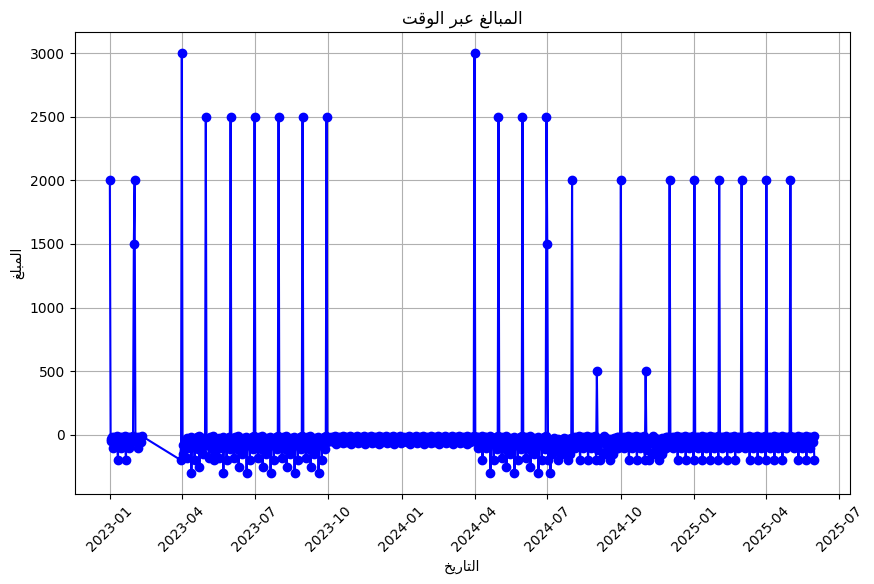

In [ ]:
# إعداد النصوص العربية
def arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)  # إعادة تشكيل النصوص
    return get_display(reshaped_text)  # تنسيق النص ليظهر بشكل صحيح

# إنشاء الرسم البياني
plt.figure(figsize=(10, 6))
plt.plot(df['التاريخ'], df['المبلغ'], marker='o', linestyle='-', color='b')
plt.title(arabic_text('المبالغ عبر الوقت'))
plt.xlabel(arabic_text('التاريخ'))
plt.ylabel(arabic_text('المبلغ'))
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


/tmp/ipython-input-32-3271953138.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='النوع', y='المبلغ', data=df, palette='Set2')


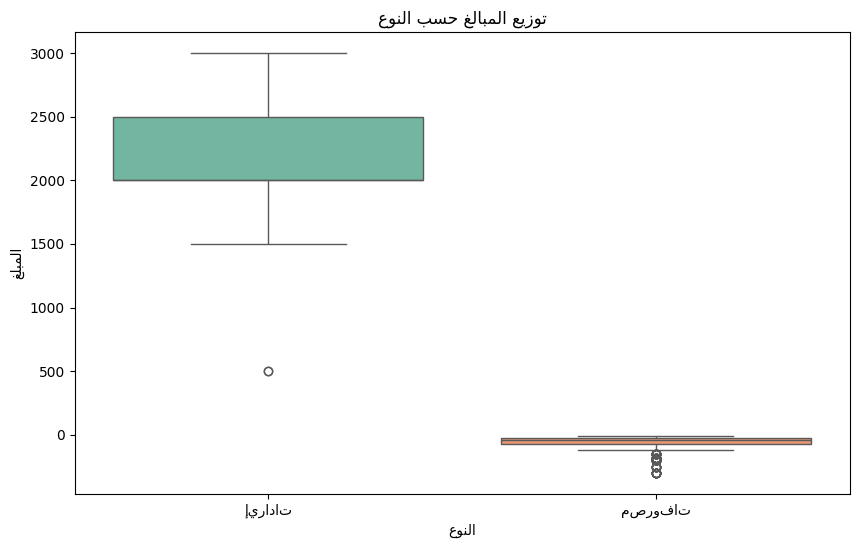

In [ ]:
# إعداد النصوص العربية
def arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)  # إعادة تشكيل النصوص
    return get_display(reshaped_text)  # تنسيق النص ليظهر بشكل صحيح

# رسم Boxplot لعرض المبالغ حسب النوع
plt.figure(figsize=(10, 6))
sns.boxplot(x='النوع', y='المبلغ', data=df, palette='Set2')
plt.title(arabic_text('توزيع المبالغ حسب النوع'))
plt.xlabel(arabic_text('النوع'))
plt.ylabel(arabic_text('المبلغ'))
plt.show()


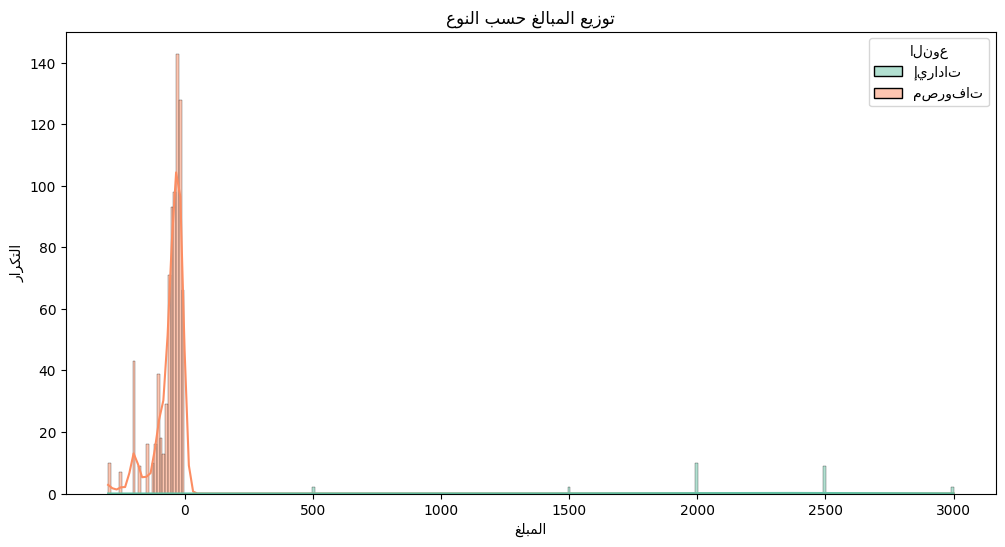

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='المبلغ', hue='النوع', kde=True, palette="Set2")
plt.title(arabic_text('توزيع المبالغ حسب النوع'))
plt.xlabel(arabic_text('المبلغ'))
plt.ylabel(arabic_text('التكرار'))
plt.show()


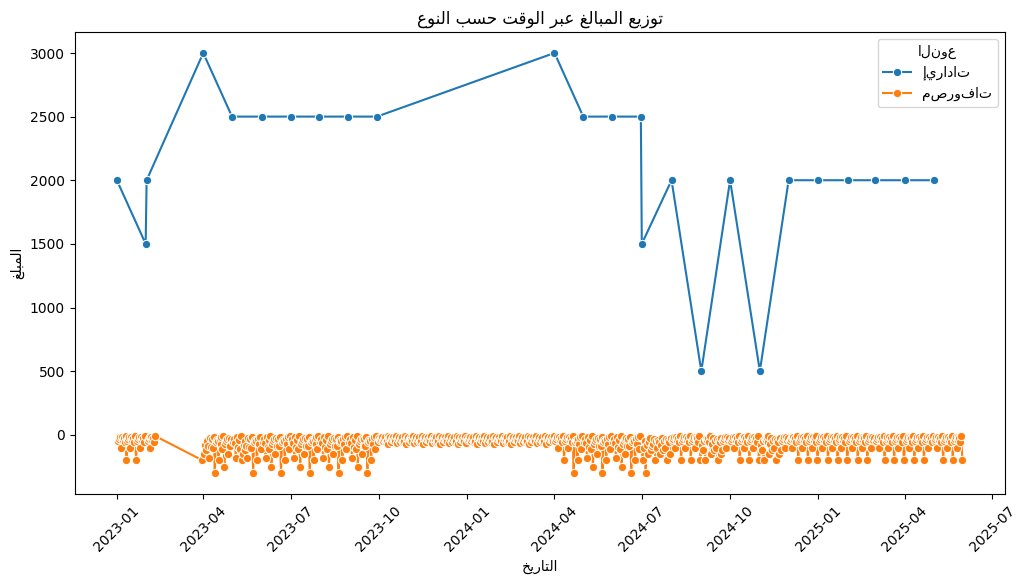

In [ ]:
# تجميع البيانات حسب التاريخ والنوع
df['التاريخ'] = pd.to_datetime(df['التاريخ'])
df_grouped = df.groupby(['التاريخ', 'النوع'])['المبلغ'].sum().reset_index()

# رسم Lineplot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='التاريخ', y='المبلغ', hue='النوع', marker='o')
plt.title(arabic_text('توزيع المبالغ عبر الوقت حسب النوع'))
plt.xlabel(arabic_text('التاريخ'))
plt.ylabel(arabic_text('المبلغ'))
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd

# تحميل البيانات
df = pd.read_csv("/content/Arabic Transactions.csv")

# # حذف عمود التاريخ الأصلي بعد استخراج الميزات
# df.drop(columns=["التاريخ","الرصيد"], inplace=True)

# عرض أول 5 صفوف للتحقق
df


,التاريخ,المبلغ,الوصف,النوع,القسم,القسم الفرعي
0,2023-01-01,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,إيرادات,الدخل,الراتب
1,2023-01-02,-50.0,شراء ببطاقة الخصم FRESHMART,مصروفات,المصروفات,الطعام
2,2023-01-03,-30.0,شراء ببطاقة الخصم SHELL,مصروفات,المصروفات,المواصالت
3,2023-01-04,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,مصروفات,المصروفات,الطعام
4,2023-01-05,-100.0,خصم آلي FITLIFE GYM اشتراك,مصروفات,المصروفات,الصحة
...,...,...,...,...,...,...
829,2025-05-27,-40.0,شراء ببطاقة الخصم متجر األدوات الصحية أدوات,مصروفات,التسوق,أدوات منزلية
830,2025-05-28,-25.0,دفع رسوم تجديد رخصة,مصروفات,الخدمات الحكومية,المرور
831,2025-05-29,-60.0,دفع فاتورة المياه من شركة المياه,مصروفات,المرافق,المياه
832,2025-05-30,-10.0,شراء ببطاقة الخصم متجر النباتات نباتات,مصروفات,التسوق,نباتات


In [ ]:
df["النوع"].unique()

array(['إيرادات', 'مصروفات'], dtype=object)

In [ ]:
# تحويل العمود 'التاريخ' إلى نوع تاريخي
df['التاريخ'] = pd.to_datetime(df['التاريخ'], errors='coerce')

# استخراج السنة والشهر واليوم من التاريخ
df['السنة'] = df['التاريخ'].dt.year
df['الشهر'] = df['التاريخ'].dt.month
df['اليوم'] = df['التاريخ'].dt.day
df = df.drop(columns=['التاريخ'])

# عرض أول 5 صفوف للتأكد من التحويل
df.head()


,المبلغ,الوصف,النوع,القسم,القسم الفرعي,السنة,الشهر,اليوم
0,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,إيرادات,الدخل,الراتب,2023,1,1
1,-50.0,شراء ببطاقة الخصم FRESHMART,مصروفات,المصروفات,الطعام,2023,1,2
2,-30.0,شراء ببطاقة الخصم SHELL,مصروفات,المصروفات,المواصالت,2023,1,3
3,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,مصروفات,المصروفات,الطعام,2023,1,4
4,-100.0,خصم آلي FITLIFE GYM اشتراك,مصروفات,المصروفات,الصحة,2023,1,5


In [ ]:
df.shape

(834, 8)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# تحويل الأعمدة النصية إلى قيم عددية
label_encoder = LabelEncoder()

df['النوع'] = label_encoder.fit_transform(df['النوع'])
df['القسم'] = label_encoder.fit_transform(df['القسم'])
df['القسم الفرعي'] = label_encoder.fit_transform(df['القسم الفرعي'])

# عرض أول 5 صفوف للتأكد من التحويل
df.head()


,المبلغ,الوصف,النوع,القسم,القسم الفرعي,السنة,الشهر,اليوم
0,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,0,10,14,2023,1,1
1,-50.0,شراء ببطاقة الخصم FRESHMART,1,14,20,2023,1,2
2,-30.0,شراء ببطاقة الخصم SHELL,1,14,34,2023,1,3
3,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,1,14,20,2023,1,4
4,-100.0,خصم آلي FITLIFE GYM اشتراك,1,14,18,2023,1,5


In [ ]:
df

,المبلغ,الوصف,النوع,القسم,القسم الفرعي,السنة,الشهر,اليوم
0,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,0,10,14,2023,1,1
1,-50.0,شراء ببطاقة الخصم FRESHMART,1,14,20,2023,1,2
2,-30.0,شراء ببطاقة الخصم SHELL,1,14,34,2023,1,3
3,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,1,14,20,2023,1,4
4,-100.0,خصم آلي FITLIFE GYM اشتراك,1,14,18,2023,1,5
...,...,...,...,...,...,...,...,...
829,-40.0,شراء ببطاقة الخصم متجر األدوات الصحية أدوات,1,5,2,2025,5,27
830,-25.0,دفع رسوم تجديد رخصة,1,8,33,2025,5,28
831,-60.0,دفع فاتورة المياه من شركة المياه,1,13,36,2025,5,29
832,-10.0,شراء ببطاقة الخصم متجر النباتات نباتات,1,5,42,2025,5,30


In [ ]:
# حفظ البيانات بصيغة CSV
df.to_csv("Transactions.csv", index=False, encoding="utf-8-sig")

In [ ]:
df

,المبلغ,الوصف,النوع,القسم,القسم الفرعي,السنة,الشهر,اليوم
0,2000.0,إيداع مباشر شركة ABC الراتب الرقم المرجعي,0,10,14,2023,1,1
1,-50.0,شراء ببطاقة الخصم FRESHMART,1,14,20,2023,1,2
2,-30.0,شراء ببطاقة الخصم SHELL,1,14,34,2023,1,3
3,-20.0,شراء ببطاقة الخصم OLIVE GARDEN,1,14,20,2023,1,4
4,-100.0,خصم آلي FITLIFE GYM اشتراك,1,14,18,2023,1,5
...,...,...,...,...,...,...,...,...
829,-40.0,شراء ببطاقة الخصم متجر األدوات الصحية أدوات,1,5,2,2025,5,27
830,-25.0,دفع رسوم تجديد رخصة,1,8,33,2025,5,28
831,-60.0,دفع فاتورة المياه من شركة المياه,1,13,36,2025,5,29
832,-10.0,شراء ببطاقة الخصم متجر النباتات نباتات,1,5,42,2025,5,30


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib
from imblearn.over_sampling import SMOTE

# اختيار العمود النصي كمدخل (X) والعمود الهدف (y)
X = df["الوصف"]
y = df["النوع"]  # الهدف هو عمود النوع

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# تحويل النصوص إلى خصائص رقمية باستخدام TF-IDF
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# تدريب النموذج باستخدام Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# تقييم النموذج
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

# حفظ النموذج و الـ vectorizer في ملفات pkl
joblib.dump(model, "LogisticRegression_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")


              precision    recall  f1-score   support

           0       1.00      0.75      0.86        12
           1       0.99      1.00      0.99       239

    accuracy                           0.99       251
   macro avg       0.99      0.88      0.93       251
weighted avg       0.99      0.99      0.99       251

Model and vectorizer saved successfully!


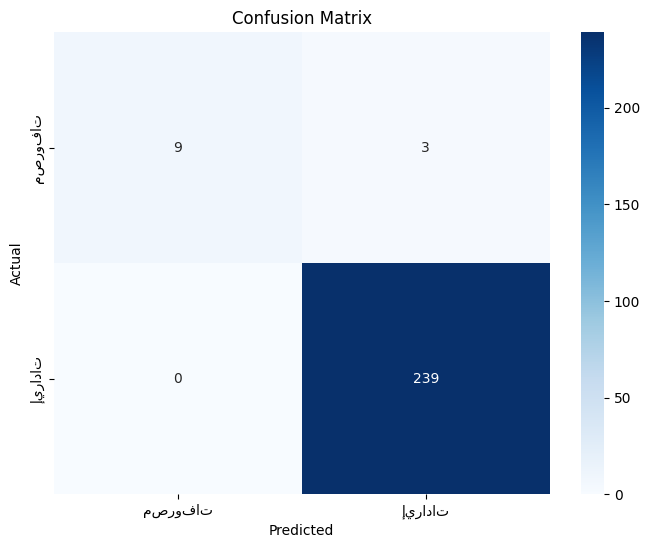

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, y_pred)

# رسم مصفوفة الارتباك
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['مصروفات', 'إيرادات'], yticklabels=['مصروفات', 'إيرادات'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# حفظ النموذج والـ vectorizer
joblib.dump(model, "log_model.pkl")
joblib.dump(vectorizer, "log_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# تحضير بياناتك
X = df.drop(columns=['النوع'])  # استبعاد العمود الذي يمثل الهدف (النوع)
y = df['النوع']  # العمود الذي يمثل الهدف (النوع)

# استخدام TF-IDF لتحويل العمود النصي 'الوصف' إلى متجهات رقمية
vectorizer = TfidfVectorizer()

# تحويل عمود الوصف إلى متجهات
X_w_description = vectorizer.fit_transform(X['الوصف'])

# تحويل الأعمدة الأخرى إلى قيم رقمية إذا كانت موجودة
X_rest = X.drop(columns=['الوصف'])

# دمج العمود المحول (الوصف) مع الأعمدة الأخرى
from scipy.sparse import hstack
X_final = hstack([X_w_description, X_rest])

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# تطبيق SMOTE على بيانات التدريب
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# الآن لديك بيانات التدريب بعد تطبيق SMOTE
print(f"قبل SMOTE: {X_train.shape}, بعد SMOTE: {X_res.shape}")

# تدريب نموذج باستخدام بيانات التدريب المعززة
model = RandomForestClassifier(random_state=42)
model.fit(X_res, y_res)

# اختبار النموذج
y_pred = model.predict(X_test)

# طباعة تقرير الأداء
print(classification_report(y_test, y_pred))


KeyError: "['النوع'] not found in axis"

In [ ]:
joblib.dump(model, "random_forest_model.pkl")
joblib.dump(vectorizer, "Random_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


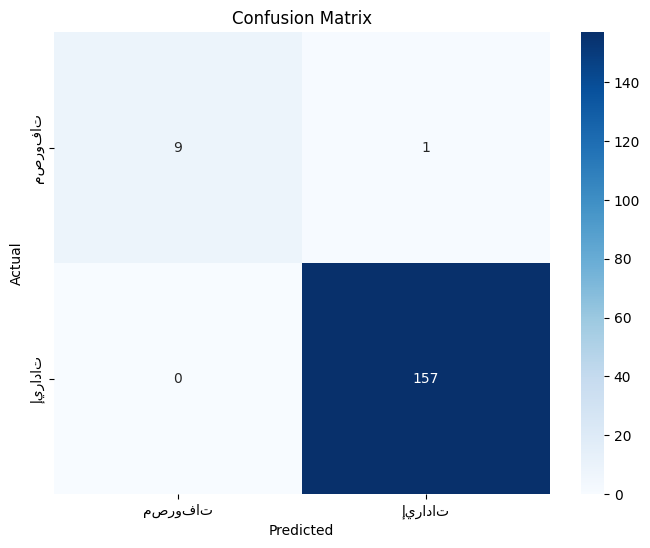

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, y_pred)

# رسم مصفوفة الارتباك
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['مصروفات', 'إيرادات'], yticklabels=['مصروفات', 'إيرادات'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report
import joblib  # مكتبة لحفظ النموذج والـ vectorizer

# تحضير بياناتك
X = df.drop(columns=['النوع'])  # استبعاد العمود الذي يمثل الهدف (النوع)
y = df['النوع']  # العمود الذي يمثل الهدف (النوع)

# استخدام TF-IDF لتحويل العمود النصي 'الوصف' إلى متجهات رقمية
vectorizer = TfidfVectorizer()

# تحويل عمود الوصف إلى متجهات
X_w_description = vectorizer.fit_transform(X['الوصف'])

# تحويل الأعمدة الأخرى إلى قيم رقمية إذا كانت موجودة
X_rest = X.drop(columns=['الوصف'])

# دمج العمود المحول (الوصف) مع الأعمدة الأخرى
from scipy.sparse import hstack
X_final = hstack([X_w_description, X_rest])

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# تطبيق SMOTE على بيانات التدريب
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# الآن لديك بيانات التدريب بعد تطبيق SMOTE
print(f"قبل SMOTE: {X_train.shape}, بعد SMOTE: {X_res.shape}")

# تدريب نموذج XGBoost باستخدام بيانات التدريب المعززة
model = xgb.XGBClassifier(random_state=42)
model.fit(X_res, y_res)

# اختبار النموذج
y_pred = model.predict(X_test)

# طباعة تقرير الأداء
print(classification_report(y_test, y_pred))

# حفظ النموذج والـ vectorizer
joblib.dump(model, "XGBoost_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")


قبل SMOTE: (667, 248), بعد SMOTE: (1304, 248)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00       157

    accuracy                           1.00       167
   macro avg       1.00      1.00      1.00       167
weighted avg       1.00      1.00      1.00       167

Model and vectorizer saved successfully!


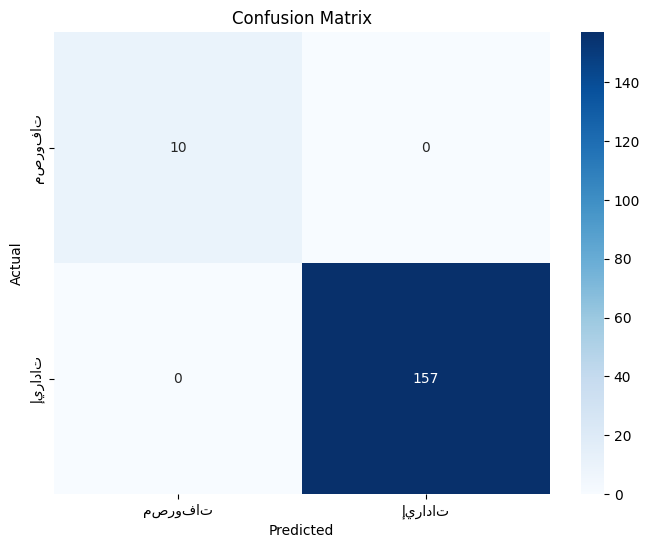

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, y_pred)

# رسم مصفوفة الارتباك
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['مصروفات', 'إيرادات'], yticklabels=['مصروفات', 'إيرادات'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import joblib
from scipy.sparse import hstack

# تحميل النموذج والـ vectorizer المحملين
loaded_model = joblib.load('XGBoost_model.pkl')
loaded_vectorizer = joblib.load('vectorizer.pkl')

def classify_transaction(transaction_description):
    # تحويل وصف المعاملة إلى متجه باستخدام الـ vectorizer المحمل
    X_new_description = loaded_vectorizer.transform([transaction_description])

    # إذا كانت هناك أعمدة أخرى (مثل السنة، الشهر، اليوم، إلخ)، تأكد من تضمينها بشكل صحيح
    # على سبيل المثال إذا كانت لديك قيمة year=2023
    X_new_rest = []  # أضف الأعمدة الأخرى هنا إذا كانت موجودة

    # دمج الوصف مع الأعمدة الأخرى (إن وجدت)
    X_new = hstack([X_new_description, X_new_rest])

    # تصنيف المعاملة باستخدام النموذج المحمل
    prediction = loaded_model.predict(X_new)

    # استرجاع التصنيف
    return prediction[0]

# اختبار التصنيف على معاملة جديدة
transaction_description = "إيداع :مباشر شركة ABC ( )الراتب - الرقم :المرجعي 123456"
main_cat = classify_transaction(transaction_description)
print(f"التصنيف المتوقع: {main_cat}")


ValueError: Feature shape mismatch, expected: 248, got 242

In [ ]:
from sklearn.metrics import confusion_matrix

# إنشاء مصفوفة الالتباس (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred_rf)

print("مصفوفة الالتباس:")
print(conf_matrix)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# حساب مصفوفة الالتباس
cm = confusion_matrix(y_test, y_pred_rf)

# رسم مصفوفة الالتباس
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['إيرادات', 'مصروفات'], yticklabels=['إيرادات', 'مصروفات'])
plt.xlabel('التصنيف المتوقع')
plt.ylabel('التصنيف الفعلي')
plt.title('مصفوفة الالتباس')
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# تحديد النموذج
model = RandomForestClassifier()

# إجراء Cross-Validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)  # تقسيم البيانات لـ 5 أقسام

# طباعة متوسط الدقة عبر الـ Cross-Validation
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f}")


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# رسم منحنى التعلم
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(), X_train, y_train, cv=5, scoring='accuracy')

# حساب المتوسطات
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Test Accuracy')

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=0.1, penalty='l2')

model.fit(X_train, y_train)

# التنبؤ بالقيم على بيانات الاختبار
y_pred_lg = model.predict(X_test)

# تقييم النموذج
accuracy = accuracy_score(y_test, y_pred_lg)
print(f"Accuracy of Naive Bayes: {accuracy * 100:.2f}%")


In [ ]:
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()

# تدريب النموذج
model_nb.fit(X_train, y_train)

# التنبؤ بالقيم على بيانات الاختبار
y_pred_nb = model_nb.predict(X_test)

# تقييم النموذج
accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of Naive Bayes: {accuracy * 100:.2f}%")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# إنشاء نموذج KNN
model_knn = KNeighborsClassifier(n_neighbors=3)

# تدريب النموذج
model_knn.fit(X_train, y_train)

# التنبؤ بالقيم على بيانات الاختبار
y_pred_knn = model_knn.predict(X_test)

# تقييم النموذج
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy of KNN: {accuracy * 100:.2f}%")


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# تدريب نموذج Naive Bayes على البيانات
def train_model(data):
    # تنظيف النصوص
    df["الوصف"] = df["الوصف"].apply(lambda x: x.lower())  # تحويل النص إلى حروف صغيرة
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(df["الوصف"])

    # تدريب نموذج الفئات الرئيسية
    main_categories = df["النوع"]
    main_model = MultinomialNB()
    X_train_main, X_test_main, Y_train_main, Y_test_main = train_test_split(X, main_categories, test_size=0.3, random_state=42)
    main_model.fit(X_train_main, Y_train_main)

    # تقرير الأداء
    Y_pred_main = main_model.predict(X_test_main)
    print("تقرير الأداء للفئات الرئيسية:\n", classification_report(Y_test_main, Y_pred_main))

    # حفظ النموذج
    joblib.dump(main_model, "category_model.pkl")
    joblib.dump(vectorizer, "vectorize.pkl")

# تدريب النموذج على بيانات التصنيف
train_model(df)


تقرير الأداء للفئات الرئيسية:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       1.00      1.00      1.00       239

    accuracy                           0.99       251
   macro avg       0.96      0.96      0.96       251
weighted avg       0.99      0.99      0.99       251



**تصنيف المعاملات الجديدة:**

In [ ]:
# تصنيف المعاملات الجديدة
def classify_transaction(description):
    main_model = joblib.load("/content/category_model.pkl")
    vectorizer = joblib.load("/content/vectorize.pkl")

    # تحويل الوصف إلى تمثيل عددي
    description_vectorized = vectorizer.transform([description])

    # تصنيف الفئة الرئيسية
    main_category = main_model.predict(description_vectorized)[0]

    return main_category

# اختبار التصنيف على معاملة جديدة
transaction_description = "إيداع :مباشر شركة ABC ( )الراتب - الرقم :المرجعي 123456"

main_cat = classify_transaction(transaction_description)
print(f"التصنيف المتوقع: {main_cat}")


التصنيف المتوقع: 0


**4. إرجاع النتائج للمستخدم:**

In [ ]:
# import pandas as pd

# # إخراج البيانات بتنسيق JSON
# def output_as_json(df):
#     return df.to_json(orient='records', force_ascii=False)

# # مثال على إخراج البيانات المصفاة بتنسيق JSON
# json_data = output_as_json(df)
# print(json_data)


import pandas as pd

# إخراج البيانات بتنسيق JSON
def output_as_json(df):
    json_data = df.to_json(orient='records', force_ascii=False, indent=4)

    # حفظ البيانات في ملف
    with open("classified_data.json", "w", encoding="utf-8") as f:
        f.write(json_data)

    print("✅ تم حفظ البيانات في classified_data.json")

# مثال على استخدام الدالة
output_as_json(df)


✅ تم حفظ البيانات في classified_data.json


**إخراج البيانات بتنسيق SQL:**

In [ ]:
import sqlite3

# إخراج البيانات إلى قاعدة بيانات SQL
def output_as_sql(data):
    conn = sqlite3.connect('financial_data.db')
    data.to_sql('transactions', conn, if_exists='replace', index=False)
    conn.commit()
    conn.close()

# مثال على إخراج البيانات بتنسيق SQL
output_as_sql(df)


In [ ]:
df

In [ ]:
def classify_transaction(description):
    main_model = joblib.load("/content/random_forest_model.pkl")
    vectorizer = joblib.load("/content/Random_vectorizer.pkl")

    description_cleaned = clean_text(description)
    description_vectorized = vectorizer.transform([description_cleaned])

    main_category = main_model.predict(description_vectorized)[0]

    return main_category
# تصنيف معاملة جديدة والتأكد من دقة التصنيف
def test_classification_on_example(df):
    # اختر أمثلة من البيانات لاختبار التصنيف
    example_texts = df['الوصف'].sample(5).tolist()
    example_labels = df['النوع'].sample(5).tolist()

    for description, true_label in zip(example_texts, example_labels):
        predicted_main = classify_transaction(description)
        print(f"الوصف: {description}")
        print(f"التصنيف المتوقع: {predicted_main}")
        print(f"التصنيف الفعلي: {true_label}")
        print('-' * 50)

# اختبار التصنيف على أمثلة
test_classification_on_example(df)


In [ ]:
transaction_description = "إيداع :مباشر شركة ABC ( )الراتب - الرقم :المرجعي 123456"
main_cat = classify_transaction(transaction_description)
print(f"التصنيف المتوقع: {main_cat}")


التصنيف المتوقع: 0


In [ ]:
df.head()


In [ ]:
!pip install fastapi uvicorn
!pip install pyngrok
!pip install pymupdf
!pip install python-multipart
!pip install PyPDF2
!pip install pdfplumber



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 86.8 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI, UploadFile, File
import fitz  # PyMuPDF
import re
import joblib
import json
from pyngrok import ngrok
import uvicorn
import nest_asyncio
from fastapi import FastAPI, UploadFile, File
import fitz  # PyMuPDF
import joblib
import re
from pyngrok import ngrok
import uvicorn

app = FastAPI()

# تحميل النموذج و الـ vectorizer
model = joblib.load("/content/category_model.pkl")
vectorizer = joblib.load("/content/vectorize.pkl")

# استخراج النص من PDF
def extract_text_from_pdf(file_path):
    doc = fitz.open(file_path)
    text = ""
    for page in doc:
        text += page.get_text("text")
    return text

# تنظيف النص
def clean_text(text):
    text = re.sub(r"[^\w\s.-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# التحقق من إن كان السطر عنوان جدول
def is_header_line(text):
    header_keywords = ["التاريخ", "المبلغ", "الوصف", "الرصيد", "النوع", "القسم", "القسم الفرعي"]
    return any(keyword in text for keyword in header_keywords)

# تصنيف باستخدام النموذج المدرب
def classify_with_model(transaction):
    cleaned = clean_text(transaction)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    return prediction[0]

@app.post("/process-file")
async def process_file(file: UploadFile = File(...)):
    contents = await file.read()
    file_path = f"/tmp/{file.filename}"

    with open(file_path, 'wb') as f:
        f.write(contents)

    if not file.filename.endswith('.pdf'):
        return {"error": "Unsupported file format. Please upload a PDF file."}

    raw_text = extract_text_from_pdf(file_path)
    lines = raw_text.split("\n")
    transactions = []
    for line in lines:
        clean_line = clean_text(line)
        if not is_header_line(clean_line):
            transactions.append(clean_line)

    result = []
    for transaction in transactions:
        category = classify_with_model(transaction)
        result.append({
            "text": transaction,
            "category": category
        })

    return {"transactions": result}


# NGROK and run
ngrok.set_auth_token("2w9xGxAvHLQdIoZSShkjDooZpQz_3RhUfP2TezsP3vehcsdr")
public_url = ngrok.connect(8000)
print("Public URL:", public_url)

nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)



ERROR:pyngrok.process.ngrok:t=2025-07-19T15:18:46+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2025-07-19T15:18:46+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok st

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n.

In [ ]:
!pkill ngrok


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib

# تدريب نموذج Naive Bayes على البيانات
def train_model(df):
    # تنظيف النصوص
    df["الوصف"] = df["الوصف"].apply(lambda x: x.lower())  # تحويل النص إلى حروف صغيرة
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(df["الوصف"])
    y = df["النوع"]

    # موازنة البيانات باستخدام SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # تقسيم البيانات
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

    # تدريب النموذج
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # تقييم النموذج
    y_pred = model.predict(X_test)
    print("تقرير الأداء بعد تطبيق SMOTE:\n", classification_report(y_test, y_pred))

    # حفظ النموذج والمتجه
    joblib.dump(model, "model.pkl")
    joblib.dump(vectorizer, "V.pkl")
    print("✅ تم حفظ النموذج والمتجه بنجاح.")

# استدعاء الدالة
train_model(df)


تقرير الأداء بعد تطبيق SMOTE:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       252

    accuracy                           1.00       486
   macro avg       1.00      1.00      1.00       486
weighted avg       1.00      1.00      1.00       486

✅ تم حفظ النموذج والمتجه بنجاح.


In [ ]:
import joblib
import pandas as pd

# تحميل النموذج والمحول
model = joblib.load("/content/c_model.pkl")
vectorizer = joblib.load("/content/vecrize.pkl")

# بيانات جديدبيانات وصف بالعربي لتجربتها
texts = [
    "دفع فاتورة الكهرباء",
    "ايداع من عميل",
    "اشتراك في منصة شاهد",
    "راتب شهري",
    "شراء دواء من الصيدلية",
    "قبض من فريلانسر",
    "دفع اشتراك الإنترنت",
    "عمولة من موقع خمسات",
    "تذكرة مترو",
    "شراء مستلزمات من السوبر ماركت"
]

# تحويل البيانات لإطار بيانات
df = pd.DataFrame({'الوصف': texts})

# تحويل النصوص إلى تمثيل رقمي باستخدام vectorizer
X = vectorizer.transform(df['الوصف'])

# توقع التصنيفات
predictions = model.predict(X)

# عرض النتائج
df['التصنيف المتوقع'] = predictions
print(df)



                           الوصف  التصنيف المتوقع
0            دفع فاتورة الكهرباء                1
1                  ايداع من عميل                1
2            اشتراك في منصة شاهد                1
3                      راتب شهري                1
4          شراء دواء من الصيدلية                1
5                قبض من فريلانسر                1
6            دفع اشتراك الإنترنت                1
7            عمولة من موقع خمسات                1
8                     تذكرة مترو                1
9  شراء مستلزمات من السوبر ماركت                1


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import pandas as pd

# تأكد إن عندك DataFrame df فيه عمود "الوصف" و"النوع"

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
import joblib

def train_model(df):
    # تنظيف النصوص
    df["الوصف"] = df["الوصف"].astype(str).apply(lambda x: x.lower())

    # تحويل النصوص إلى خصائص رقمية
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(df["الوصف"])
    y = df["النوع"]

    # توازن البيانات باستخدام RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y)

    # تقسيم البيانات
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

    # تدريب النموذج
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # تقييم النموذج
    y_pred = model.predict(X_test)
    print("تقرير الأداء بعد التوازن:\n", classification_report(y_test, y_pred))

    # حفظ النموذج والـ vectorizer
    joblib.dump(model, "c_model.pkl")
    joblib.dump(vectorizer, "vecrize.pkl")

# مثال على الاستخدام
train_model(df)


تقرير الأداء بعد التوازن:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       174

    accuracy                           1.00       324
   macro avg       1.00      1.00      1.00       324
weighted avg       1.00      1.00      1.00       324



In [ ]:
import joblib

# تحميل النموذج والـ Vectorizer
model = joblib.load("/content/c_model.pkl")
vectorizer = joblib.load("/content/vecrize.pkl")

# جمل للاختبار
test_sentences = [
    "ايداع من عميل",
    "دفع فاتورة النت",
    "قبض راتب شهري",
    "شراء دواء",
    "عمولة من مستقل"
]

# تحويلها إلى تمثيل عددي
X_test = vectorizer.transform([text.lower() for text in test_sentences])

# التنبؤ
predictions = model.predict(X_test)

# عرض النتائج
for text, pred in zip(test_sentences, predictions):
    print(f"الوصف: {text} ➤ التصنيف المتوقع: {'إيراد' if pred == 1 else 'مصروفات'}")


الوصف: ايداع من عميل ➤ التصنيف المتوقع: إيراد
الوصف: دفع فاتورة النت ➤ التصنيف المتوقع: إيراد
الوصف: قبض راتب شهري ➤ التصنيف المتوقع: إيراد
الوصف: شراء دواء ➤ التصنيف المتوقع: إيراد
الوصف: عمولة من مستقل ➤ التصنيف المتوقع: إيراد
